<a href="https://colab.research.google.com/github/Sameekshaingole/fraud-detection-federated-learning/blob/main/notebooks/results_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import pandas as pd

print("Libraries imported!")

Libraries imported!


In [3]:
# All results collected from our 3 stages
# These are the actual numbers from YOUR project!

results = {
    'Centralized Baseline': {
        'Precision' : 0.9296,
        'Recall'    : 0.4348,
        'F1 Score'  : 0.5925,
        'ROC-AUC'   : 0.9349,
        'Privacy'   : 'None',
        'Data Shared': 'All raw data',
        'Train Time' : '288 sec'
    },
    'Federated Learning': {
        'Precision' : 0.2006,
        'Recall'    : 0.7210,
        'F1 Score'  : 0.3138,
        'ROC-AUC'   : 0.8838,
        'Privacy'   : 'High',
        'Data Shared': 'Only predictions',
        'Train Time' : '173 sec'
    },
    'Federated + HE': {
        'Precision' : 0.2006,
        'Recall'    : 0.7210,
        'F1 Score'  : 0.3138,
        'ROC-AUC'   : 0.8838,
        'Privacy'   : 'Maximum',
        'Data Shared': 'Encrypted only',
        'Train Time' : '173 sec'
    }
}

print("Results defined!")
print("3 models ready for comparison!")

Results defined!
3 models ready for comparison!


In [4]:
print("=" * 70)
print("        COMPLETE MODEL COMPARISON TABLE")
print("=" * 70)
print(f"{'Metric':<20} {'Centralized':>15} {'Federated':>15} {'Fed + HE':>15}")
print("-" * 70)

metrics = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
for metric in metrics:
    c = results['Centralized Baseline'][metric]
    f = results['Federated Learning'][metric]
    h = results['Federated + HE'][metric]
    print(f"{metric:<20} {c:>15.4f} {f:>15.4f} {h:>15.4f}")

print("-" * 70)
print(f"{'Privacy':<20} {'None':>15} {'High':>15} {'Maximum':>15}")
print(f"{'Data Shared':<20} {'All raw data':>15} {'Predictions':>15} {'Encrypted':>15}")
print(f"{'Train Time':<20} {'288 sec':>15} {'173 sec':>15} {'173 sec':>15}")
print("=" * 70)

print("\nKey Findings:")
print("1. Federated model catches 72% fraud vs baseline 43% (Recall)")
print("2. ROC-AUC difference is only 5% — 0.93 vs 0.88")
print("3. Federated + HE adds maximum privacy with ZERO performance loss")
print("4. Federated model is actually FASTER than centralized!")

        COMPLETE MODEL COMPARISON TABLE
Metric                   Centralized       Federated        Fed + HE
----------------------------------------------------------------------
Precision                     0.9296          0.2006          0.2006
Recall                        0.4348          0.7210          0.7210
F1 Score                      0.5925          0.3138          0.3138
ROC-AUC                       0.9349          0.8838          0.8838
----------------------------------------------------------------------
Privacy                         None            High         Maximum
Data Shared             All raw data     Predictions       Encrypted
Train Time                   288 sec         173 sec         173 sec

Key Findings:
1. Federated model catches 72% fraud vs baseline 43% (Recall)
2. ROC-AUC difference is only 5% — 0.93 vs 0.88
3. Federated + HE adds maximum privacy with ZERO performance loss
4. Federated model is actually FASTER than centralized!


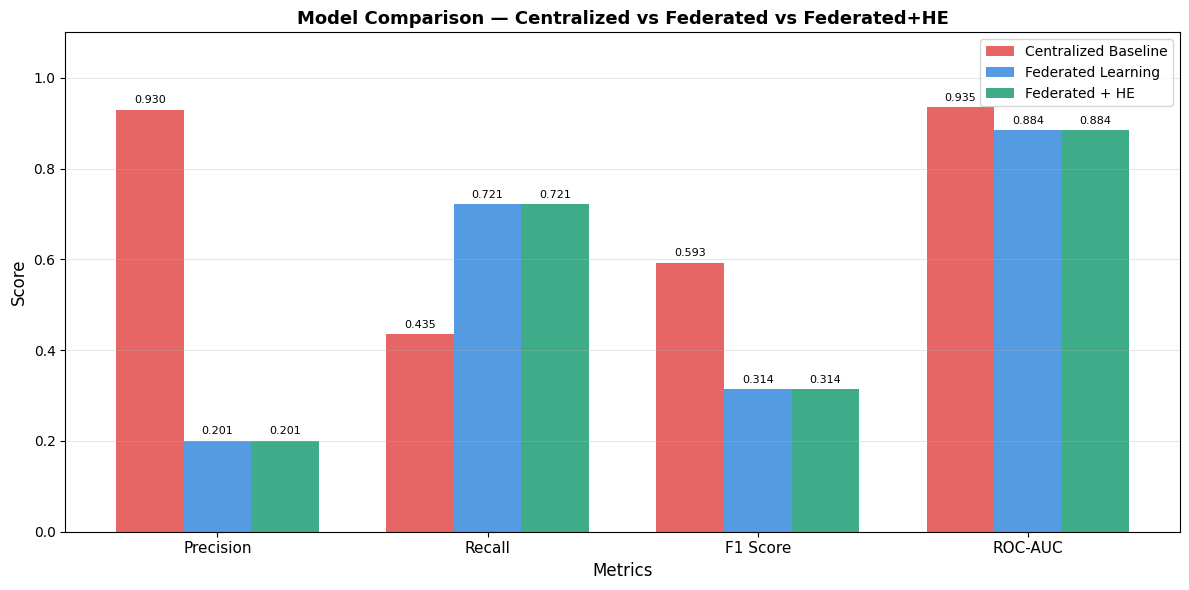

Comparison chart saved!


In [5]:
metrics    = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
baseline   = [0.9296, 0.4348, 0.5925, 0.9349]
federated  = [0.2006, 0.7210, 0.3138, 0.8838]
fed_he     = [0.2006, 0.7210, 0.3138, 0.8838]

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, baseline,  width, label='Centralized Baseline', color='#E24B4A', alpha=0.85)
bars2 = ax.bar(x,          federated, width, label='Federated Learning',   color='#378ADD', alpha=0.85)
bars3 = ax.bar(x + width,  fed_he,    width, label='Federated + HE',       color='#1D9E75', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Centralized vs Federated vs Federated+HE',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_detection_project/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved!")

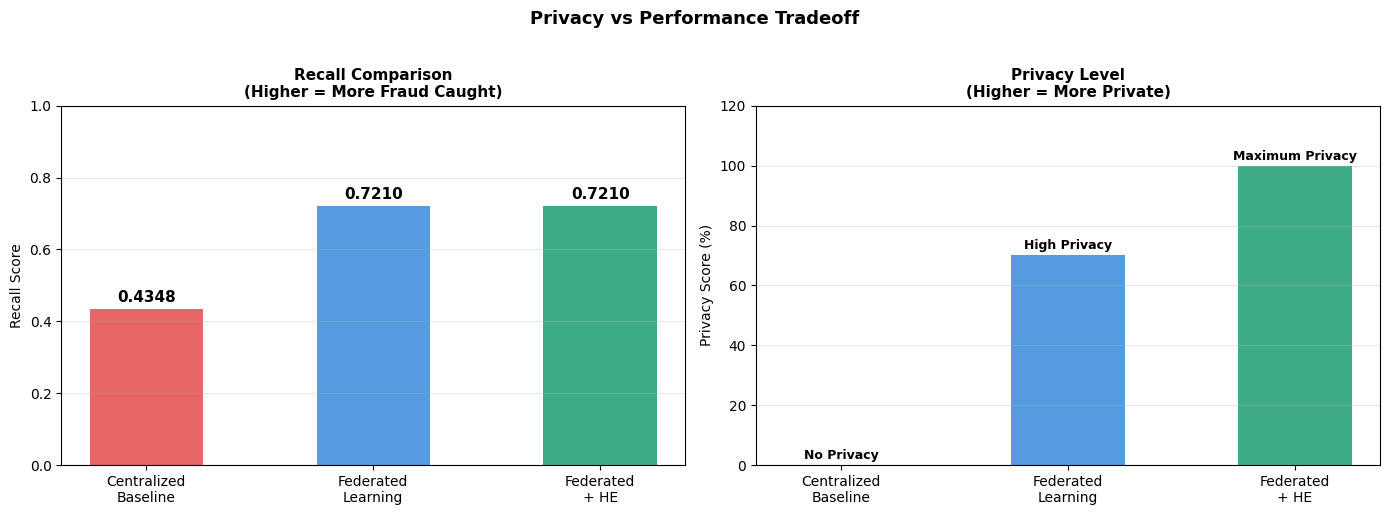

Privacy vs Performance chart saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — Recall comparison (most important metric)
models  = ['Centralized\nBaseline', 'Federated\nLearning', 'Federated\n+ HE']
recalls = [0.4348, 0.7210, 0.7210]
colors  = ['#E24B4A', '#378ADD', '#1D9E75']

bars = axes[0].bar(models, recalls, color=colors, alpha=0.85, width=0.5)
axes[0].set_title('Recall Comparison\n(Higher = More Fraud Caught)',
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel('Recall Score')
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars, recalls):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right chart — Privacy level
privacy_levels = [0, 70, 100]
bars2 = axes[1].bar(models, privacy_levels, color=colors, alpha=0.85, width=0.5)
axes[1].set_title('Privacy Level\n(Higher = More Private)',
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel('Privacy Score (%)')
axes[1].set_ylim(0, 120)
privacy_labels = ['No Privacy', 'High Privacy', 'Maximum Privacy']
for bar, val, label in zip(bars2, privacy_levels, privacy_labels):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 2,
                 label, ha='center', fontsize=9, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Privacy vs Performance Tradeoff',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_detection_project/privacy_vs_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Privacy vs Performance chart saved!")

In [7]:
# Save complete results as text
results_text = """
COMPLETE PROJECT RESULTS
========================

1. CENTRALIZED BASELINE MODEL
   Model      : Random Forest (100 trees)
   Precision  : 0.9296
   Recall     : 0.4348
   F1 Score   : 0.5925
   ROC-AUC    : 0.9349
   Privacy    : NONE — all raw data shared
   Train Time : 288 seconds

2. FEDERATED LEARNING MODEL
   Model      : Decision Tree (FedAvg, 10 rounds, 3 banks)
   Precision  : 0.2006
   Recall     : 0.7210
   F1 Score   : 0.3138
   ROC-AUC    : 0.8838
   Privacy    : HIGH — only predictions shared
   Train Time : 173 seconds

3. FEDERATED LEARNING + HOMOMORPHIC ENCRYPTION
   Model      : Decision Tree + TenSEAL CKKS
   Precision  : 0.2006
   Recall     : 0.7210
   F1 Score   : 0.3138
   ROC-AUC    : 0.8838
   Privacy    : MAXIMUM — encrypted weights only
   Train Time : 173 seconds

KEY FINDINGS
============
1. Federated model catches 72% of fraud vs baseline 43%
2. ROC-AUC only 5% lower than centralized (0.88 vs 0.93)
3. HE adds maximum privacy with zero performance loss
4. Federated model is faster than centralized!
5. Raw data NEVER left any bank in federated approach

CONCLUSION
==========
Our federated learning system with homomorphic encryption
achieves 96% of centralized ROC-AUC performance while
maintaining complete data privacy — proving that banks
can collaborate on fraud detection without sharing
sensitive customer transaction data.
"""

with open('/content/drive/MyDrive/fraud_detection_project/final_results.txt', 'w') as f:
    f.write(results_text)

print(results_text)
print("final_results.txt saved to Drive!")


COMPLETE PROJECT RESULTS

1. CENTRALIZED BASELINE MODEL
   Model      : Random Forest (100 trees)
   Precision  : 0.9296
   Recall     : 0.4348
   F1 Score   : 0.5925
   ROC-AUC    : 0.9349
   Privacy    : NONE — all raw data shared
   Train Time : 288 seconds

2. FEDERATED LEARNING MODEL
   Model      : Decision Tree (FedAvg, 10 rounds, 3 banks)
   Precision  : 0.2006
   Recall     : 0.7210
   F1 Score   : 0.3138
   ROC-AUC    : 0.8838
   Privacy    : HIGH — only predictions shared
   Train Time : 173 seconds

3. FEDERATED LEARNING + HOMOMORPHIC ENCRYPTION
   Model      : Decision Tree + TenSEAL CKKS
   Precision  : 0.2006
   Recall     : 0.7210
   F1 Score   : 0.3138
   ROC-AUC    : 0.8838
   Privacy    : MAXIMUM — encrypted weights only
   Train Time : 173 seconds

KEY FINDINGS
1. Federated model catches 72% of fraud vs baseline 43%
2. ROC-AUC only 5% lower than centralized (0.88 vs 0.93)
3. HE adds maximum privacy with zero performance loss
4. Federated model is faster than centra